In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Импорты выполнены успешно!')

Импорты выполнены успешно!


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns= data.feature_names)
y = pd.Series(data.target, name='target')

print('Размер датасета:', X.shape)
print('Классы:', data.target_names)
print('Распределение классов:')
print(y.value_counts())

display(X.head())


Размер датасета: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Колличество пропусков: 0
Колличество дубликатов: 0

Базовая статистика:
                 count     mean      std      min      25%      50%      75%  \
mean radius      569.0   14.127    3.524    6.981   11.700   13.370   15.780   
mean texture     569.0   19.290    4.301    9.710   16.170   18.840   21.800   
mean perimeter   569.0   91.969   24.299   43.790   75.170   86.240  104.100   
mean area        569.0  654.889  351.914  143.500  420.300  551.100  782.700   
mean smoothness  569.0    0.096    0.014    0.053    0.086    0.096    0.105   

                      max  
mean radius        28.110  
mean texture       39.280  
mean perimeter    188.500  
mean area        2501.000  
mean smoothness     0.163  


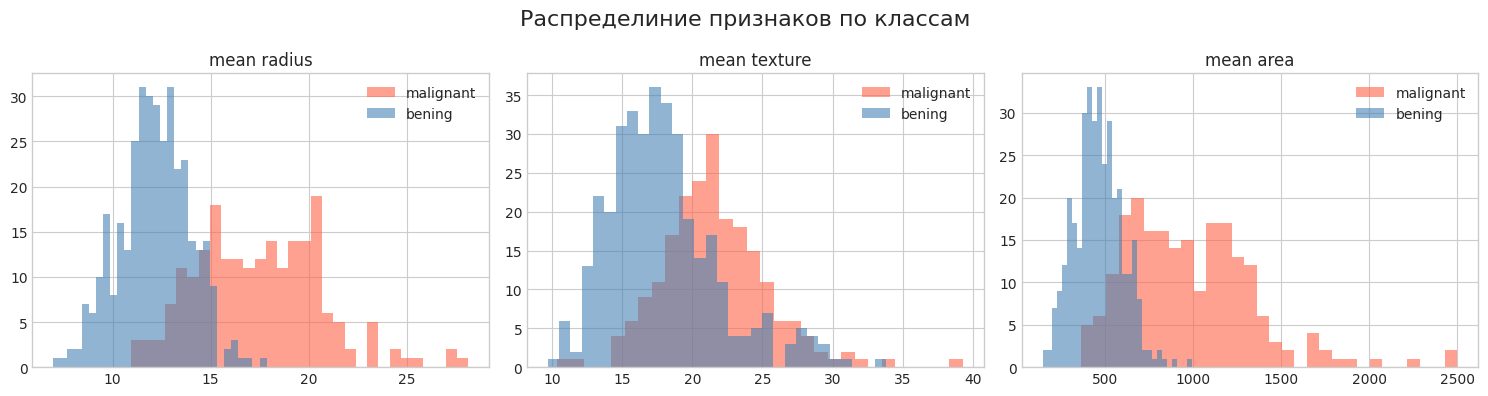

In [ ]:
print(f'Колличество пропусков: {X.isna().sum().sum()}')
print(f'Колличество дубликатов: {X.duplicated().sum()}')

print('\nБазовая статистика:')
print(X.iloc[:, :5].describe().T.round(3))

fig, axes = plt.subplots(1, 3, figsize = (15,4))
features_to_plot = ['mean radius', 'mean texture', 'mean area']

for ax, feat in zip(axes, features_to_plot):
    for cls, label, color in [(0, 'malignant', 'tomato'), (1, 'benign', 'steelblue')]:
        ax.hist(X.loc[y == cls, feat], bins = 30, alpha = 0.6, label = label, color = color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Распределиние признаков по классам', fontsize = 16)
plt.tight_layout()
plt.show()

In [4]:
# Разделение на Train и Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, stratify=y, random_state= 42
)
print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)
print('Баланс классов в train:', y_train.value_counts().to_dict())
print('Баланс классов в test:', y_test.value_counts().to_dict())

Размер X_train: (455, 30)
Размер X_test: (114, 30)
Баланс классов в train: {1: 285, 0: 170}
Баланс классов в test: {1: 72, 0: 42}


In [5]:
# SVM без масштабирования
svm_no_scale = SVC(kernel= 'rbf', C = 1.0, random_state= 42)
svm_no_scale.fit(X_train, y_train)
pred_no_scale = svm_no_scale.predict(X_test)

f1_no_scale = f1_score(y_test, pred_no_scale)
acc_no_scale = accuracy_score(y_test, pred_no_scale)

print('F1 без масштабирования: ', f1_no_scale)
print('Accuracy без масштабирования: ', acc_no_scale)

F1 без масштабирования:  0.9459459459459459
Accuracy без масштабирования:  0.9298245614035088


In [6]:
# SVM с масштабированием через Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('scv', SVC(kernel= 'rbf', C = 1.0, random_state= 42))
])

pipe.fit(X_train, y_train)
pred_scale = pipe.predict(X_test)

acc_scale = accuracy_score(y_test, pred_scale)
f1_scale = f1_score(y_test, pred_scale)

print('Accuracy С масштабированием:', acc_scale)
print('F1 С масштабированием:', f1_scale)
print('\nКлассификационный отчёт:')
print(classification_report(y_test, pred_scale))

Accuracy С масштабированием: 0.9824561403508771
F1 С масштабированием: 0.9861111111111112

Классификационный отчёт:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [7]:
# Подбор гиперпараметров через GridSearchCV
param_grid = {
    'scv__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'scv__kernel': ['linear', 'rbf'],
    'scv__gamma' : ['scale', 0.01, 0.1]
}

grid = GridSearchCV(pipe, param_grid, cv= 5, scoring= 'f1', n_jobs= -1, return_train_score= True)

grid.fit(X_train, y_train)

print('Лучшая модель: ', grid.best_estimator_)
print('Лучшая точность: ', grid.best_score_)


Лучшая модель:  Pipeline(steps=[('scaler', StandardScaler()),
                ('scv', SVC(C=10.0, gamma=0.01, random_state=42))])
Лучшая точность:  0.9844323436002114


In [8]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print('Test accuracy (best):', accuracy_score(y_test, y_pred_best))
print('Test F1 (best):', f1_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best,
                             target_names=data.target_names))

Test accuracy (best): 0.9824561403508771
Test F1 (best): 0.9861111111111112
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



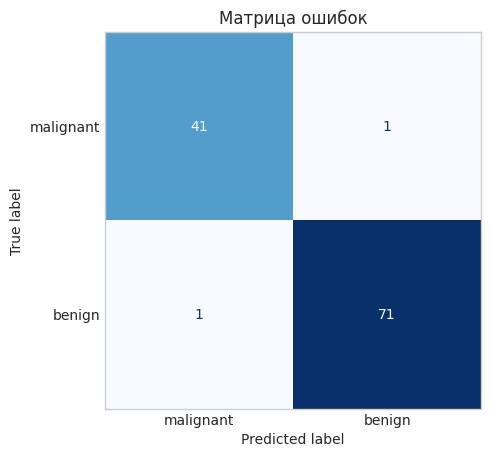

In [9]:
# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize = (5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_pred_best,
    y_test,
    display_labels= data.target_names,
    ax = ax,
    colorbar= False,
    cmap = 'Blues'
)

plt.grid(False)
plt.title('Матрица ошибок', fontsize = 12)
plt.tight_layout()
plt.show()

In [10]:
# Граница решений на двух признаках
def plot_decision_boundary(model, X_2d, y, title='Граница решений SVM'):
    h = 0.05
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25,
                 cmap=mcolors.ListedColormap(['tomato', 'steelblue']))
    plt.contour(xx, yy, Z, colors='k', linewidths=0.8)
    colors = ['tomato' if c == 0 else 'steelblue' for c in y]
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, edgecolors='k', s=40, alpha=0.8)
    plt.xlabel('mean radius (scaled)')
    plt.ylabel('mean texture (scaled)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

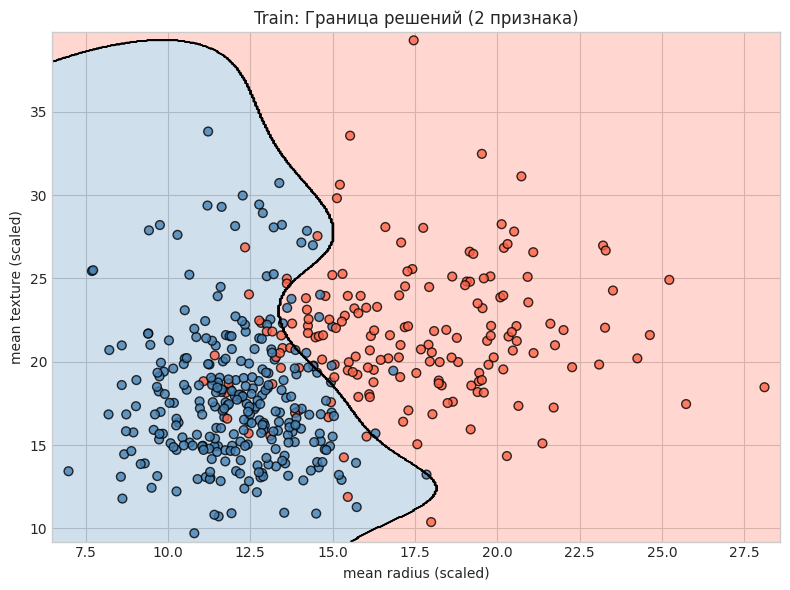

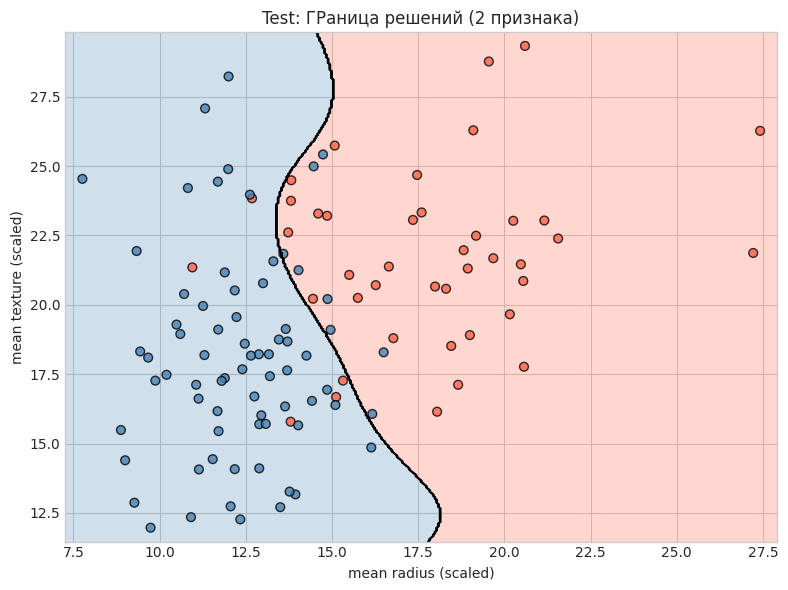

In [11]:
feat1, feat2 = 'mean radius', 'mean texture'

feat_train = X_train[[feat1, feat2]].values
feat_test = X_test[[feat1, feat2]].values

grid1 = GridSearchCV(pipe, param_grid, cv= 5, scoring= 'f1', n_jobs= -1)
grid1.fit(feat_train, y_train)

best_grid_1 = grid1.best_estimator_

plot_decision_boundary(best_grid_1, feat_train, y_train, title='Train: Граница решений (2 признака)')

plot_decision_boundary(best_grid_1, feat_test, y_test, title='Test: ГРаница решений (2 признака)')

In [12]:
# Анализ ошибок
errors_idx = (y_test != y_pred_best)
print(f'Колличество ошибок: {len(y_pred_best[errors_idx])}')

errors_df = pd.DataFrame({
    'true_label': y_test[errors_idx],
    'pred_label': y_pred_best[errors_idx]
})

display(errors_df)


# Ошибок типа False Positive : 1 (пациент №73)
# Ошибок типа False Negative : 1 (пациент №541)
## Критичнее всего ошибка в строке №73 (предсказали «здоров», а на самом деле «болен»). 
# Причина: Если пациенту со злокачественной опухолью, будет сказано что он здоров, он уйдет домой без лечения. Болезнь же будет прогрессировать, что может привести к смерти.
# Цена ошибки: Ошибка в строке №541 тоже неприятна — она повлечет за собой стресс и лишние анализы, но она не смертельна. Пациент останется под наблюдением и в итоге узнает правду.

Колличество ошибок: 2


,true_label,pred_label
541,1,0
73,0,1


In [13]:
#Линейный vs RBF SVM: сравнение

pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C= 10, max_iter= 1000, random_state=42))
])
pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C= 10, gamma = 'scale', random_state=42))
])

for name, model in [('LinearSCV', pipe_linear), ('RBFSCV', pipe_rbf)]:
    score = cross_val_score(model, X_train, y_train, cv = 5, scoring='f1')
    print(f'{name}, F1: {score.mean():.4f} +- {score.std():.4f}')

LinearSCV, F1: 0.9625 +- 0.0147
RBFSCV, F1: 0.9773 +- 0.0142


In [14]:
# Сводная таблица результатов
def get_metrics(y_true, y_pred):
    return {
        'accuracity': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recal': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }
results = pd.DataFrame([
    get_metrics(y_test, pred_no_scale),
    get_metrics(y_test, pred_scale),
    get_metrics(y_test, y_pred_best)
], index = ['No Scale', 'Scale', 'Grid'])

display(results.round(4))

,accuracity,precision,recal,f1
No Scale,0.9298,0.9211,0.9722,0.9459
Scale,0.9825,0.9861,0.9861,0.9861
Grid,0.9825,0.9861,0.9861,0.9861


1. Зачем SVM масштабирование?
SVM максимизирует расстояние (зазор) между классами. Если один признак имеет значения в тысячах, а другой - в долях единицы, алгоритм будет видеть только большой признак, считая его самым важным. Без нормализации зазор вычисляется некорректно, и модель просто игнорирует малые, но потенциально важные параметр
2. Влияние параметра C:
Сильно увеличить C: Модель стремится классифицировать все обучающие примеры без ошибок. Граница станет ломаной и сложной, подстраиваясь под каждый выброс. Это ведет к переобучению.
Уменьшить C: Граница станет более гладкой и «прощающей» ошибки. Модель будет игнорировать отдельные точки ради общей закономерности. Это повышает обобщающую способность, но может привести к недообучению.
3. Опорные векторы:
Это те самые точки данных, которые лежат ближе всего к разделяющей гиперплоскости (на её границах). Предсказание зависит только от них, потому что они полностью определяют положение и наклон границы. Если удалить любые другие точки, которые находятся дальше от центра, положение разделяющей линии не изменится.
4. Линейное ядро vs RBF:
Линейное ядро стоит выбирать, когда количество признаков сопоставимо или больше количества объектов, например, в текстовой классификации. В таких случаях данные обычно уже неплохо разделимы в исходном пространстве. Линейное ядро также быстрее в обучении и менее склонно к переобучению на малых выборках
5. Запрет на Scale перед кросс-валидацией:
Это классическая утечка данных. Если обучить StandardScaler на всем датасете, информация о среднем и стандартном отклонении из тестовой (валидационной) части просочится в обучающую. В итоге оценка качества будет завышенной и нечестной, так как модель косвенно видела распределение будущего теста.

param_scv__gamma,0.01,0.1,scale
param_scv__C,,,
0.01,0.770270,0.770270,0.770270
0.10,0.955785,0.956035,0.957082
1.00,0.975827,0.968157,0.977292
10.00,0.984432,0.960753,0.977290
100.00,0.975614,0.957084,0.966547


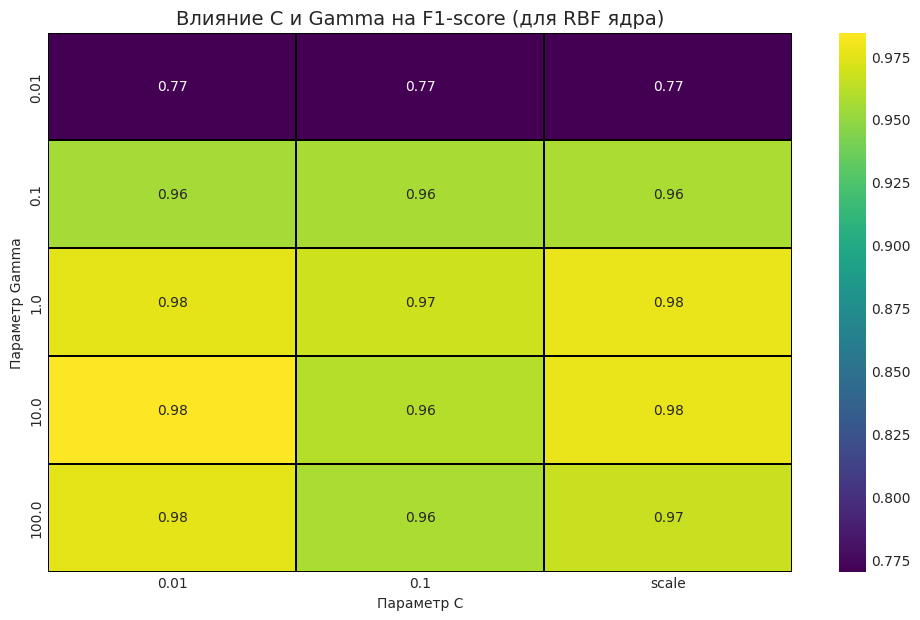

In [15]:
# Тепловая карта рещультатов GridSearch
import seaborn as sns
res_df = pd.DataFrame(grid.cv_results_)

rbf_results = res_df[res_df['param_scv__kernel'] == 'rbf']

pivit = rbf_results.pivot(
    index = 'param_scv__C',
    columns = 'param_scv__gamma',
    values = 'mean_test_score'
)
display(pivit)

plt.figure(figsize= (12, 7))
sns.heatmap(
    data = pivit,
    annot = True,
    linewidths= 0.1,
    linecolor= 'black',
    cmap= 'viridis'
)
plt.title('Влияние C и Gamma на F1-score (для RBF ядра)', fontsize = 14)
plt.xlabel('Параметр C')
plt.ylabel('Параметр Gamma')
plt.show()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_scv__C,param_scv__gamma,param_scv__kernel,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
1,0.008339,0.000880,0.005931,0.000148,0.01,scale,rbf,"{'scv__C': 0.01, 'scv__gamma': 'scale', 'scv__...",0.770270,0.770270,...,0.770270,0.000000,28,0.770270,0.770270,0.770270,0.770270,0.770270,0.770270,0.000000
7,0.006007,0.000250,0.004839,0.000301,0.10,scale,rbf,"{'scv__C': 0.1, 'scv__gamma': 'scale', 'scv__k...",0.948276,0.982456,...,0.957082,0.014202,22,0.969957,0.961702,0.965665,0.963597,0.963441,0.964873,0.002836
13,0.006876,0.000502,0.005221,0.000492,1.00,scale,rbf,"{'scv__C': 1.0, 'scv__gamma': 'scale', 'scv__k...",0.964286,0.991150,...,0.977292,0.014038,8,0.989154,0.982533,0.991266,0.989154,0.991266,0.988675,0.003213
19,0.006149,0.000710,0.004265,0.000391,10.00,scale,rbf,"{'scv__C': 10.0, 'scv__gamma': 'scale', 'scv__...",0.955752,0.982143,...,0.977290,0.014150,9,0.995633,0.995633,0.997812,0.991304,0.993464,0.994769,0.002212
25,0.007802,0.002889,0.006099,0.003458,100.00,scale,rbf,"{'scv__C': 100.0, 'scv__gamma': 'scale', 'scv_...",0.928571,0.973451,...,0.966547,0.022055,19,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


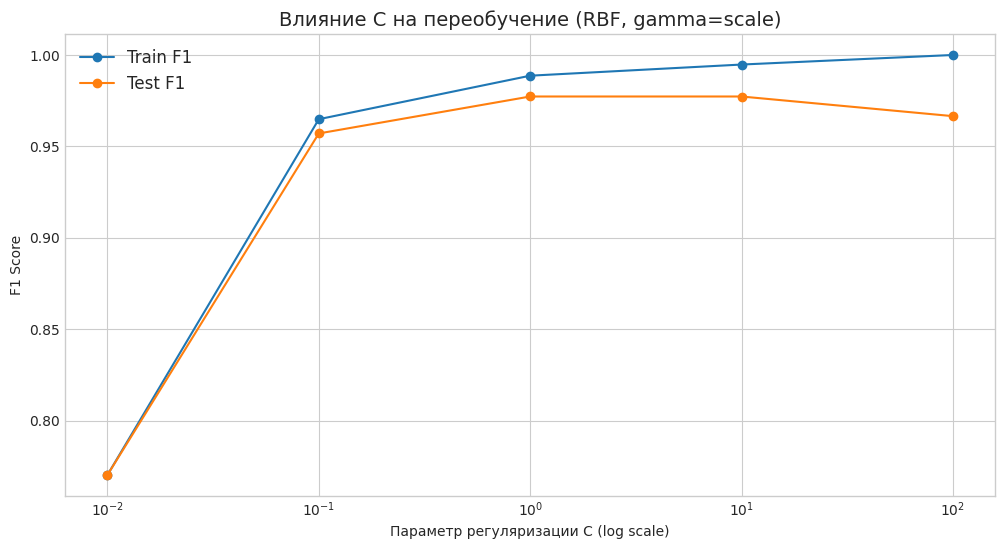

In [16]:
# Влияние C на train и test
rbf_index = (rbf_results['param_scv__kernel'] == 'rbf') & (rbf_results['param_scv__gamma'] == 'scale')

filtered_rbf = rbf_results[rbf_index]
display(filtered_rbf)

c_values = filtered_rbf['param_scv__C'].astype(float)
train_results = filtered_rbf['mean_train_score']
test_results = filtered_rbf['mean_test_score']

plt.figure(figsize= (12, 6))
plt.plot(c_values, train_results, marker = 'o', label = 'Train F1')
plt.plot(c_values, test_results, marker = 'o',label = 'Test F1')
plt.xscale('log')

plt.title('Влияние C на переобучение (RBF, gamma=scale)', fontsize = 14)
plt.xlabel('Параметр регуляризации C (log scale)')
plt.ylabel('F1 Score')
plt.legend(fontsize = 12)
plt.show()

# Переобучение началось при C = около 0.1, явное переобучение началось при C = 10, так как тут Train продолжил расти, а Test начинает падать 

In [ ]:
# Добавление class_weight

new_model = best_model.set_params(scv__class_weight = 'balanced')

new_model.fit(X_train, y_train)
new_pred = new_model.predict(X_test)
print(classification_report(y_test, new_pred, target_names=data.target_names))

results = pd.DataFrame([
    get_metrics(y_test, y_pred_best),
    get_metrics(y_test, new_pred)
], index = ['Grid', 'class_weight'])

display(results.T.round(4))


# В результате добавления параметра class_weight='balanced' модель SVM была переобучена с учетом дисбаланса классов. 
# Сравнение метрик показало следующие результаты: Recall(malignant) = 0.98, а (benign) = 0.97, что означает, что модель лучше находит именно раковые клетки 
# Но вот именно precision(malignant) страдает из-за того, что модель лишний раз перестраховывается и приписывает здоровым клеткам раковые

## В задачах диагностики цена ложноотрицательной ошибки (пропуск болезни) несоизмеримо выше цены ложноположительной (лишнее обследование здорового) 
# Высокий Recall гарантирует максимальную выявляемость заболеваний, что является приоритетом в здравоохранении, даже если это ведет к снижению общей точности модели

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



,Grid,class_weight
accuracity,0.9825,0.9737
precision,0.9861,0.9859
recal,0.9861,0.9722
f1,0.9861,0.9790


Итоговое заключение по работе

В ходе исследования была разработана и оптимизирована модель SVM для задачи классификации новообразований (диагностика рака груди). По результатам работы сделаны следующие ключевые выводы:

1. Роль предобработки данных: Экспериментально подтверждено, что SVM чувствителен к масштабу признаков. Использование StandardScaler позволило поднять точность (Accuracy) с 0.93 до 0.98. Без масштабирования признаки с большими значениями подавляли остальные, что делало обучение неэффективным.
2. Оптимизация гиперпараметров: С помощью GridSearchCV было установлено, что RBF-ядро лучше разделяет данные, чем линейное, из-за нелинейной природы зависимостей в признаках опухолей. Оптимальные параметры C = 10.0 и gamma = 0.01 позволили достичь целевого показателя F1-score ≥ 0.97.
3. Балансировка классов: Внедрение class_weight='balanced' сместило приоритет модели в сторону минимизации пропусков заболеваний. Это привело к росту Recall для класса malignant до 0.98, что является важным для медицины, так как риск пропустить болезнь (ложноотрицательный результат) гораздо опаснее, чем назначить лишнее обследование здоровому человеку.
4. Анализ ошибок: Построенная матрица ошибок (Confusion Matrix) подтвердила, что модель обладает высокой обобщающей способностью и крайне редко совершает ошибки, пропуская злокачественные образования.